# Exploratory Data Analysis (EDA): Telco Customer Churn
**Input:** `clean_churn.csv` 

## 1. Setup and load

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

df = pd.read_csv("clean_churn.csv")

print(df.shape)
df.head()

(7043, 21)


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 2. Churn distribution (the baseline)

churn
Stayed    5174
Left      1869
Name: count, dtype: int64
Churn rate: 26.5%


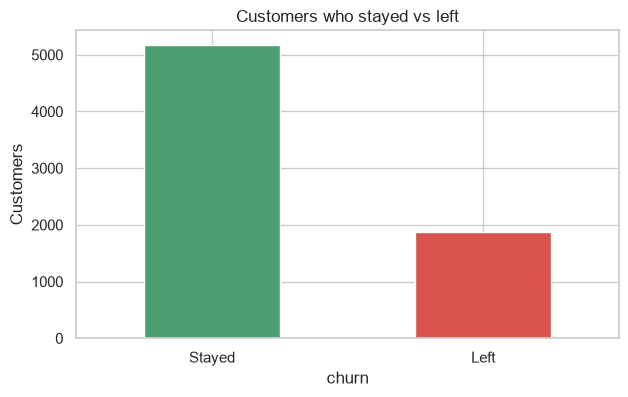

In [2]:
counts = df["churn"].value_counts().rename({0: "Stayed", 1: "Left"})
print(counts)
print("Churn rate: %.1f%%" % (100 * df["churn"].mean()))

ax = counts.plot(kind="bar", color=["#4C9F70", "#D9534F"], rot=0)
ax.set_title("Customers who stayed vs left")
ax.set_ylabel("Customers")
plt.show()

**What to look for:** about 1 in 4 customers left (26.5%). This is the **baseline**: any group above 26.5% is higher-risk than average.

Also note the data is **imbalanced** (73% stayed). 

## 3. Numeric columns vs churn

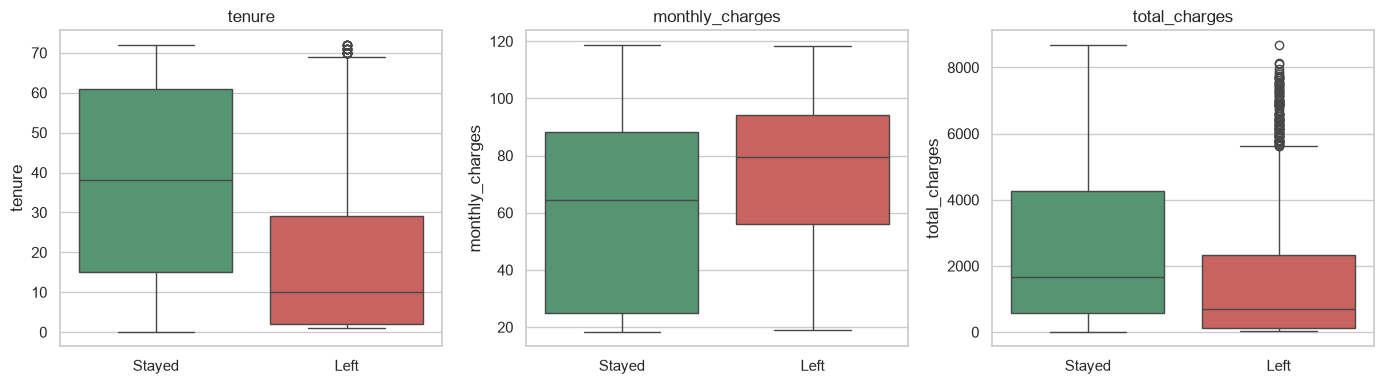

,tenure,monthly_charges,total_charges
churn,,,
0,37.6,61.3,2549.9
1,18.0,74.4,1531.8


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["tenure", "monthly_charges", "total_charges"]):
    sns.boxplot(data=df, x="churn", y=col, hue="churn", legend=False,
                palette=["#4C9F70", "#D9534F"], ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Stayed", "Left"])
    ax.set_xlabel("")
    ax.set_title(col)
plt.tight_layout()
plt.show()

df.groupby("churn")[["tenure", "monthly_charges", "total_charges"]].mean().round(1)

**What to look for:**
- **tenure:** customers who left had a much shorter tenure (median ~10 months vs ~38).
- **monthly_charges:** customers who left pay more per month (average ~$74 vs ~$61).
- **total_charges:** lower for those who left, simply because they stayed fewer months.

A box shows the middle 50% of customers; the line inside is the median.

## 4. Churn rate by category

A helper that draws the churn rate (%) for each group, with the average line (26.5%) for comparison.

In [15]:
avg = 100 * df["churn"].mean()

def churn_by(col, order=None):
    rate = (df.groupby(col)["churn"].mean() * 100).round(1)
    if order:
        rate = rate.reindex(order)
    else:
        rate = rate.sort_values(ascending=False)
    ax = rate.plot(kind="bar", color="#5B8DB8", rot=20, label="_nolegend_")
    ax.axhline(avg, color="red", linestyle="--", label=f"Average {avg:.1f}%")
    for i, v in enumerate(rate):
        ax.text(i, v + 0.8, f"{v}%", ha="center")
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel("")
    ax.legend()
    plt.show()

### 4.1 Contract type

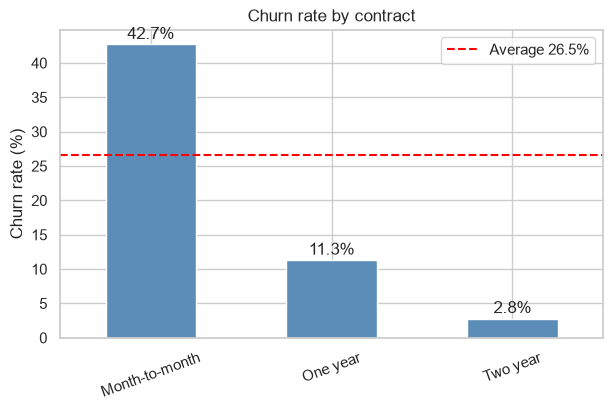

In [16]:
churn_by("contract")

**What to look for:** month-to-month customers churn at ~43%, versus ~11% (one year) and ~3% (two year). The bigger the commitment, the lower the churn.

### 4.2 Internet service (plan)

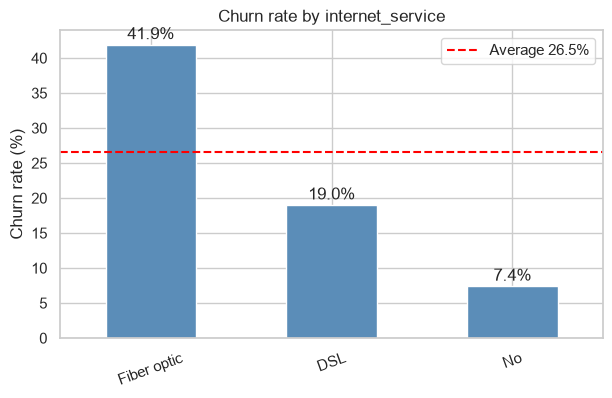

In [6]:
churn_by("internet_service")

**What to look for:** fiber optic customers churn at ~42%, more than double DSL (~19%). Customers with no internet churn the least (~7%).

### 4.3 Payment method

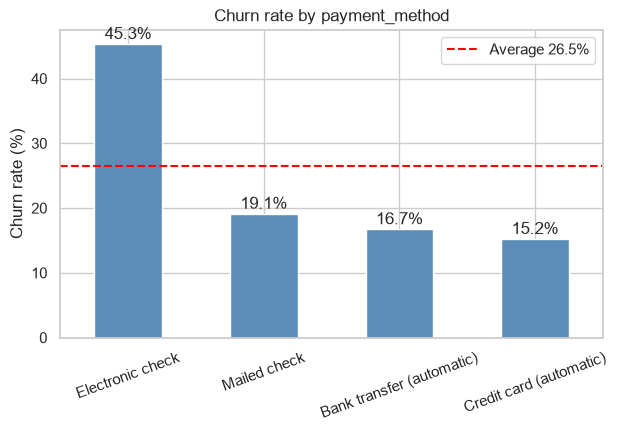

In [7]:
churn_by("payment_method")

**What to look for:** electronic check customers churn at ~45%, about three times more than customers on automatic payments (bank transfer or credit card, ~15 to 17%).

### 4.4 Support and protection services

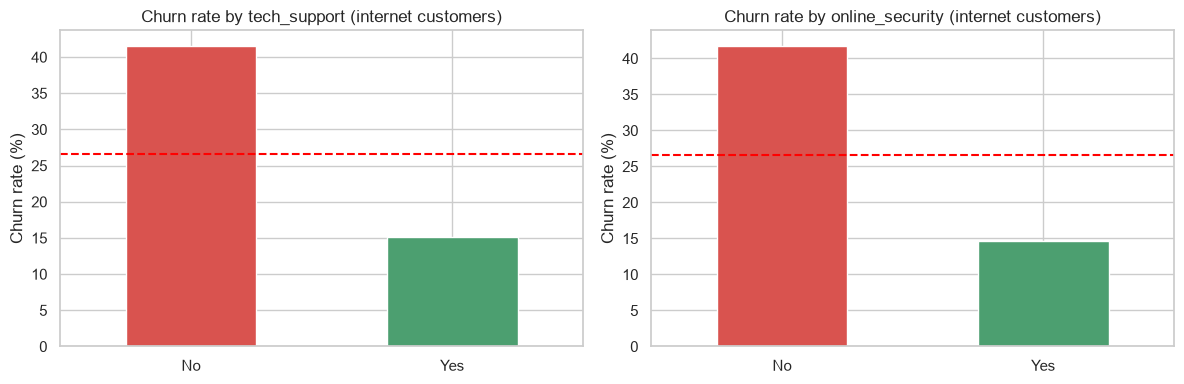

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["tech_support", "online_security"]):
    rate = (df[df["internet_service"] != "No"].groupby(col)["churn"].mean() * 100).round(1)
    rate.plot(kind="bar", color=["#D9534F", "#4C9F70"], rot=0, ax=ax)
    ax.axhline(avg, color="red", linestyle="--")
    ax.set_title(f"Churn rate by {col} (internet customers)")
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

**What to look for:** customers without tech support or online security churn far more (~42% and ~42%) than those who have them (~15% and ~15%). We only compare customers who have internet, so the comparison is fair.

### 4.5 Demographics and billing

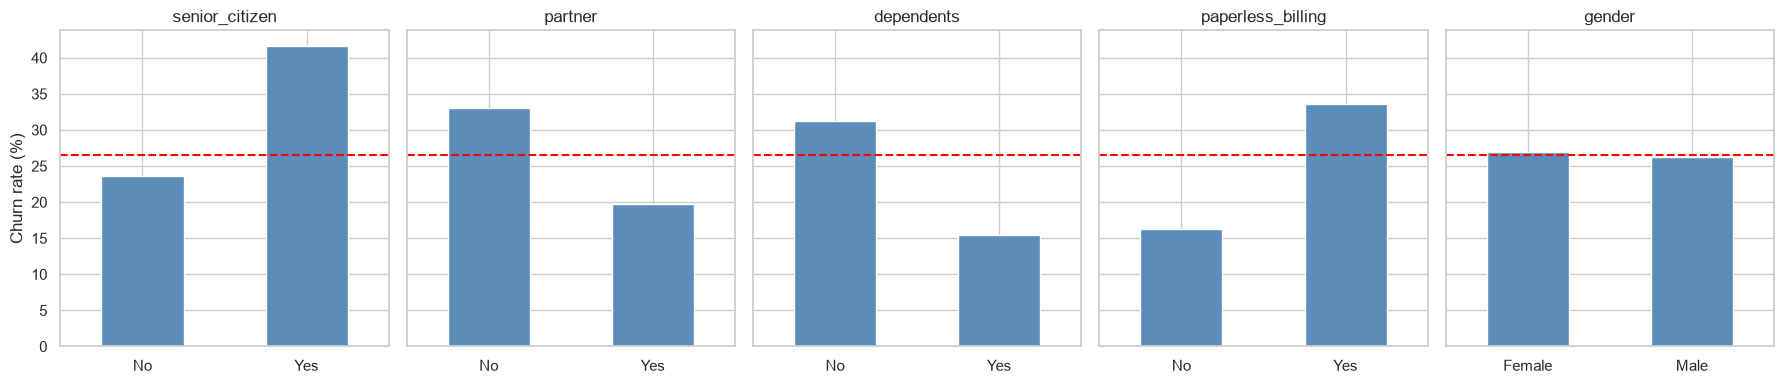

In [9]:
cols = ["senior_citizen", "partner", "dependents", "paperless_billing", "gender"]
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for ax, col in zip(axes, cols):
    rate = (df.groupby(col)["churn"].mean() * 100).round(1)
    rate.plot(kind="bar", color="#5B8DB8", rot=0, ax=ax)
    ax.axhline(avg, color="red", linestyle="--")
    ax.set_title(col)
    ax.set_xlabel("")
axes[0].set_ylabel("Churn rate (%)")
plt.tight_layout()
plt.show()

**What to look for:**
- **senior_citizen:** seniors churn at ~42% vs ~24%.
- **partner / dependents:** customers without a partner or dependents churn more.
- **paperless_billing:** paperless customers churn more (~34% vs ~16%).
- **gender:** almost no difference (~27% vs ~26%), so it is **not** a useful predictor.

## 5. Tenure groups

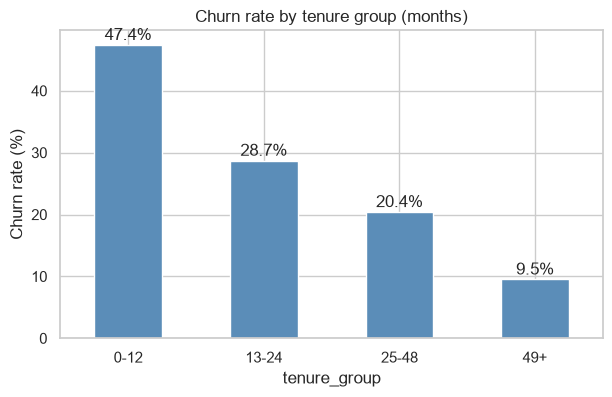

In [10]:
df["tenure_group"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
                            labels=["0-12", "13-24", "25-48", "49+"])
rate = (df.groupby("tenure_group", observed=True)["churn"].mean() * 100).round(1)
ax = rate.plot(kind="bar", color="#5B8DB8", rot=0)
for i, v in enumerate(rate):
    ax.text(i, v + 0.8, f"{v}%", ha="center")
ax.set_title("Churn rate by tenure group (months)")
ax.set_ylabel("Churn rate (%)")
plt.show()

**What to look for:** churn is highest in the first year (~47%) and falls steadily to ~9% after four years. The first 12 months are the danger zone.

## 6. Two factors together: contract and internet service

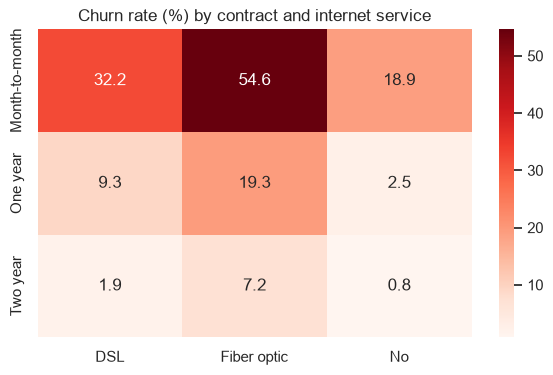

In [11]:
pivot = df.pivot_table(index="contract", columns="internet_service",
                      values="churn", aggfunc="mean") * 100
sns.heatmap(pivot.round(1), annot=True, fmt=".1f", cmap="Reds")
plt.title("Churn rate (%) by contract and internet service")
plt.ylabel("")
plt.xlabel("")
plt.show()

**What to look for:** the darkest cell is **month-to-month + fiber optic at ~55%**. Fiber customers churn more than DSL even within the same contract type, so contract alone does not explain the fiber problem.

## 7. Correlation heatmap

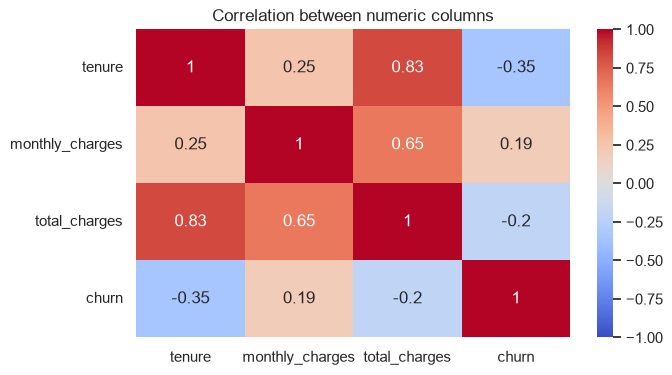

In [12]:
corr = df[["tenure", "monthly_charges", "total_charges", "churn"]].corr()
sns.heatmap(corr.round(2), annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation between numeric columns")
plt.show()

**What to look for:**
- `churn` and `tenure`: about **-0.35** (longer tenure, less churn): the strongest link with churn.
- `churn` and `monthly_charges`: about **+0.19** (higher bills, more churn).
- `tenure` and `total_charges`: about **0.83**. They are strongly related (total = months x price), so a model may not need both. 

Correlation measures a straight-line relationship between *numbers*; it does not prove cause.

## 8. Revenue impact

In [13]:
lost = df.loc[df["churn"] == 1, "monthly_charges"].sum()
total = df["monthly_charges"].sum()
print(f"Monthly revenue lost to churn: ${lost:,.0f} of ${total:,.0f} ({100 * lost / total:.1f}%)")

m2m = df["contract"] == "Month-to-month"
print(f"Month-to-month customers: {100 * m2m.mean():.1f}% of all customers")
print(f"...but {100 * df.loc[m2m, 'churn'].sum() / df['churn'].sum():.1f}% of all churners")

Monthly revenue lost to churn: $139,131 of $456,117 (30.5%)
Month-to-month customers: 55.0% of all customers
...but 88.6% of all churners


**What to look for:** churn costs about 30% of monthly revenue, and month-to-month customers produce almost 9 out of every 10 churners. That is where retention effort should go.

## 9. Business insights 

1. **One in four customers has left.** Overall churn is 26.5% (1,869 of 7,043), costing about 30% of monthly revenue.
2. **Contract length is the strongest driver.** Month-to-month customers churn at 42.7%, versus 2.8% for two-year contracts, and they make up about 89% of all churners. *Action:* offer discounts or perks to move month-to-month customers onto yearly contracts.
3. **The first year is the danger zone.** Churn is 47% for customers in their first 12 months and falls to 9.5% after four years. *Action:* invest in onboarding and early check-ins.
4. **Fiber optic customers churn twice as much as DSL.** 41.9% vs 19.0%, and the gap persists within each contract type (worst segment: month-to-month fiber at about 55%). *Action:* investigate fiber pricing and service quality.
5. **Support services protect customers.** Without tech support churn is ~42% (among internet customers) vs ~15% with it; online security shows the same pattern. *Action:* bundle or trial these services for new customers.
6. **Electronic check is a risk signal.** 45.3% churn vs 15 to 19% for other payment methods. *Action:* encourage automatic payment, for example with a small discount.
7. **Higher bills and some groups churn more; gender does not matter.** Churners pay about $13 more per month, seniors churn at 41.7%, and customers without partner or dependents churn more, while gender shows no real difference (26.9% vs 26.2%).

**Caution:** these are associations, not proven causes. Many of these factors overlap (for example, new customers are more often on month-to-month contracts), which is exactly why a predictive model is the next step.

**For the ML team:** the target is imbalanced (73/27); `tenure` and `total_charges` are highly correlated (0.83); `gender` and `phone_service` carry almost no signal.